## Direct Modulator — Sample 0 - correct

In [1]:

import gdsfactory as gf

def optical_direct_modulator():
    c = gf.Component()

    mzm = c.add_ref(gf.components.mzis.mzm(delta_length=10.0, length_y=2.0, length_x=200))
    mzm.move((0, 0))

    straight = c.add_ref(gf.components.waveguides.straight(length=10.0))
    straight.move((mzm.xmax + 10, 0))

    gf.routing.route_single(c, port1=mzm.ports['o2'], port2=straight.ports['o1'], cross_section='strip', radius=5)

    c.add_port("o1", port=mzm.ports["o1"])
    c.add_port("o2", port=straight.ports["o2"])

    c.draw_ports()
    c.plot()

    return c

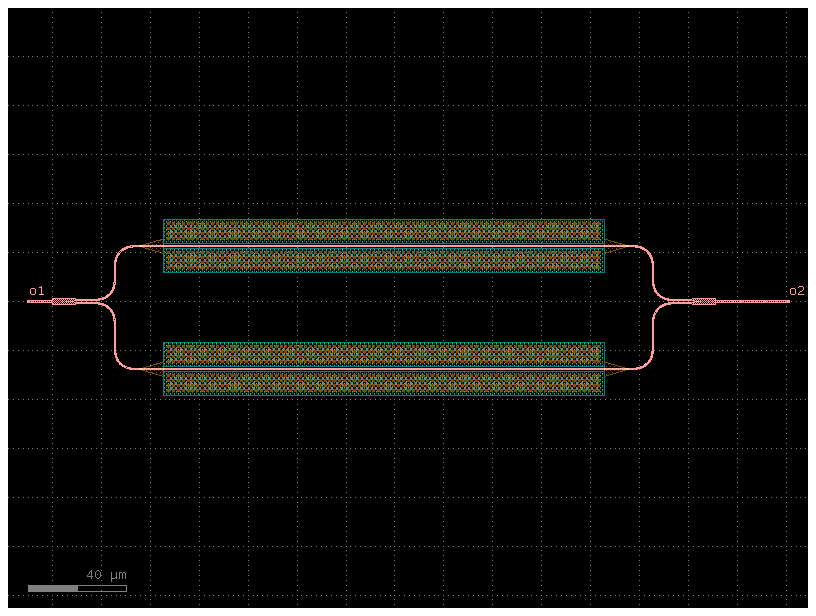

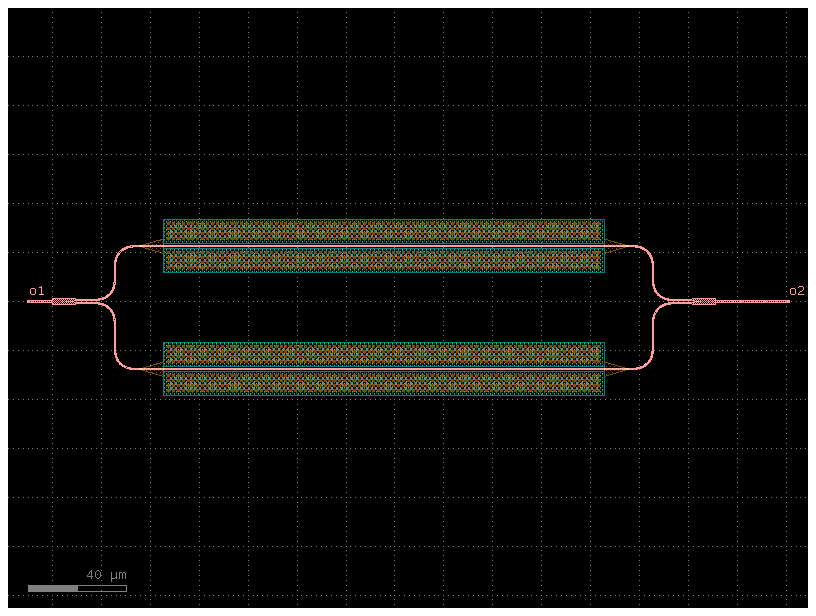

In [2]:
optical_direct_modulator()

## Direct Modulator — Sample 1 - func (wrong routing)

In [3]:

import gdsfactory as gf

def optical_direct_modulator1():
    r = gf.Component()

    mzm = r.add_ref(gf.components.mzis.mzm(delta_length=10.0, length_y=2.0, length_x=200))
    mzm.move((0, 0))

    straight = r.add_ref(gf.components.waveguides.straight(length=10.0))
    straight.move((400, 0))

    routings = [
        (mzm.ports['o1'], straight.ports['o1']),
        (mzm.ports['o2'], straight.ports['o2']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=mzm.ports["o1"])

    r.add_port("o2", port=straight.ports["o2"])

    r.draw_ports()

    r.plot()

    return r

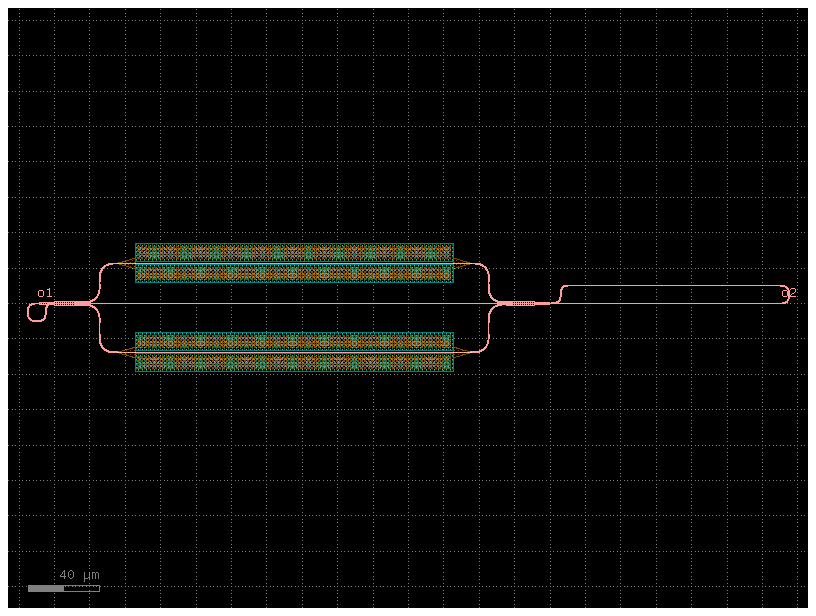

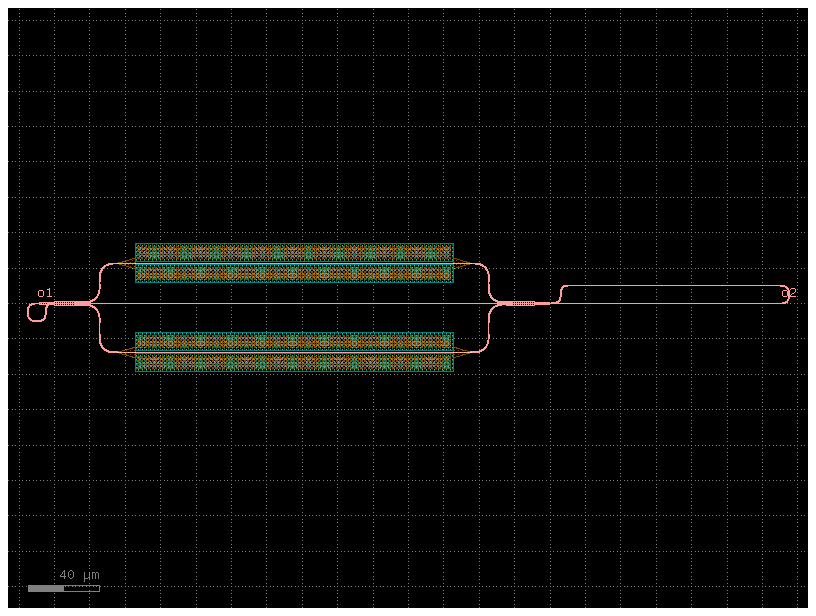

In [4]:
optical_direct_modulator1()

## Direct Modulator — Sample 2 - correct

In [6]:

import gdsfactory as gf

def optical_direct_modulator2():
    c = gf.Component()

    mzm = c.add_ref(gf.components.mzis.mzm())
    mzm.move((0, 0))

    straight = c.add_ref(gf.components.waveguides.straight(length=10))
    straight.move((mzm.xmax, 0))

    gf.routing.route_single(c, port1=mzm.ports['o2'], port2=straight.ports['o1'], cross_section='strip')

    c.add_port("o1", port=mzm.ports["o1"])
    c.add_port("o2", port=straight.ports["o2"])

    c.draw_ports()
    c.plot()

    return c


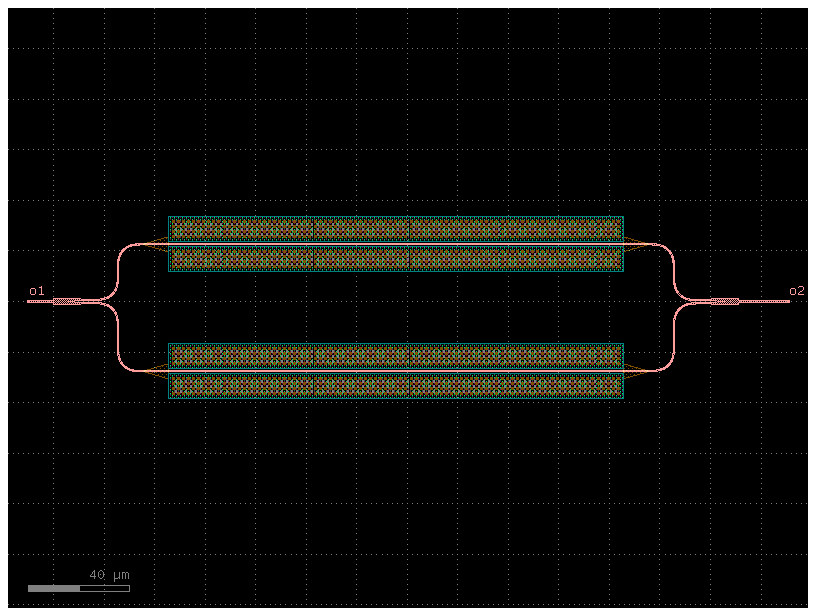

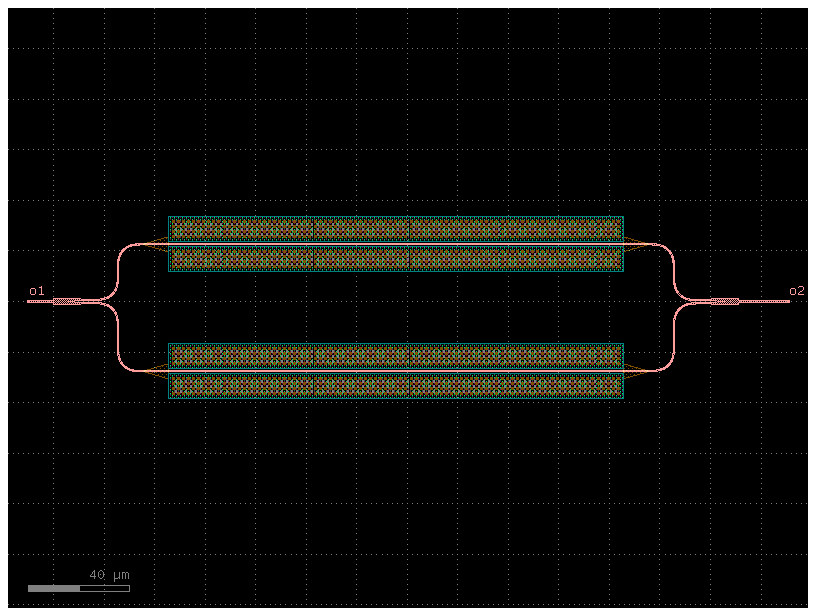

In [7]:
optical_direct_modulator2()

## 8-QAM Modulator — Sample 0

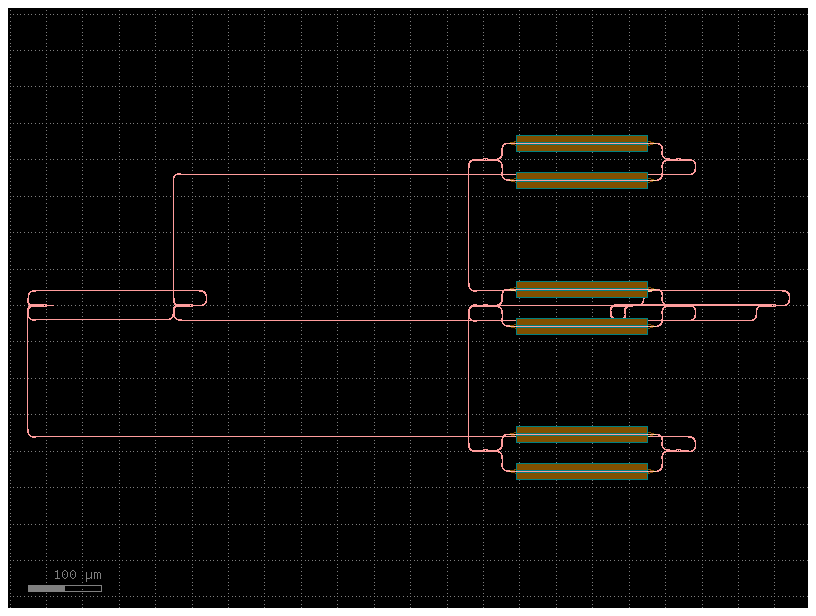

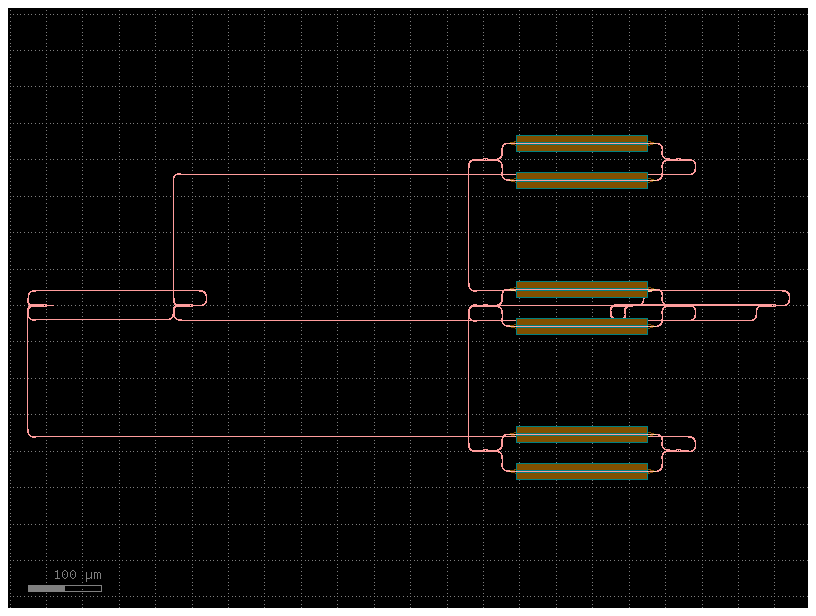

In [8]:
import gdsfactory as gf

def optical_8qam_transmitter():
    c = gf.Component()

    # Instantiate components
    mzm_bit1 = c.add_ref(gf.components.mzis.mzm())
    mzm_bit1.move((0, 200))

    mzm_bit2 = c.add_ref(gf.components.mzis.mzm())
    mzm_bit2.move((0, 0))

    mzm_bit3 = c.add_ref(gf.components.mzis.mzm())
    mzm_bit3.move((0, -200))

    splitter1 = c.add_ref(gf.components.mmis.mmi1x2())
    splitter1.move((-200, 0))
    splitter1.rotate(180)

    splitter2 = c.add_ref(gf.components.mmis.mmi1x2())
    splitter2.move((-400, 0))
    splitter2.rotate(180)

    combiner1 = c.add_ref(gf.components.mmis.mmi1x2())
    combiner1.move((400, 0))
    combiner1.rotate(180)

    combiner2 = c.add_ref(gf.components.mmis.mmi1x2())
    combiner2.move((600, 0))
    combiner2.rotate(180)

    # Connect ports
    gf.routing.route_single(c, splitter2.ports['o1'], mzm_bit1.ports['o1'],'strip')
    gf.routing.route_single(c, splitter2.ports['o2'], mzm_bit2.ports['o1'],'strip')
    gf.routing.route_single(c, splitter2.ports['o3'], mzm_bit3.ports['o1'],'strip')

    gf.routing.route_single(c, mzm_bit1.ports['o2'], combiner1.ports['o2'],'strip')
    gf.routing.route_single(c, mzm_bit2.ports['o2'], combiner1.ports['o3'],'strip')
    gf.routing.route_single(c, mzm_bit3.ports['o2'], combiner2.ports['o2'],'strip')

    gf.routing.route_single(c, splitter1.ports['o1'], splitter2.ports['o1'],'strip')
    gf.routing.route_single(c, splitter1.ports['o2'], splitter2.ports['o2'],'strip')
    gf.routing.route_single(c, splitter1.ports['o3'], splitter2.ports['o3'],'strip')

    gf.routing.route_single(c, combiner1.ports['o1'], combiner2.ports['o2'],'strip')
    gf.routing.route_single(c, combiner1.ports['o3'], combiner2.ports['o3'],'strip')

    # Expose external ports
    c.add_port("o1", port=splitter1.ports["o1"])
    c.add_port("o2", port=combiner2.ports["o1"])

    c.plot()
    return c

optical_8qam_transmitter()

## 8-QAM Modulator — Sample 1

In [ ]:
```python
import gdsfactory as gf

def optical_8_qam_transmitter():
    c = gf.Component()

    # Instantiate components
    mzm_bit1 = c.add_ref(gf.components.mzis.mzm(delta_length=10.0, length_y=2.0, length_x=200))
    mzm_bit2 = c.add_ref(gf.components.mzis.mzm(delta_length=10.0, length_y=2.0, length_x=200))
    mzm_bit3 = c.add_ref(gf.components.mzis.mzm(delta_length=10.0, length_y=2.0, length_x=200))

    splitter1 = c.add_ref(gf.components.mmis.mmi1x2())
    splitter2 = c.add_ref(gf.components.mmis.mmi1x2())

    combiner1 = c.add_ref(gf.components.mmis.mmi1x2()).mirror()
    combiner2 = c.add_ref(gf.components.mmis.mmi1x2()).mirror()

    # Move components to avoid overlap
    mzm_bit1.move((0, 100))
    mzm_bit2.move((0, 0))
    mzm_bit3.move((0, -100))

    splitter1.move((-200, 0))
    splitter2.move((-400, 0))

    combiner1.move((600, 0))
    combiner2.move((400, 0))

    # Connect ports with route_single
    gf.routing.route_single(c, port1=splitter2.ports['o1'], port2=splitter1.ports['o1'], cross_section='strip', radius=5)
    gf.routing.route_single(c, port1=splitter2.ports['o2'], port2=mzm_bit1.ports['o1'], cross_section='strip', radius=5)
    gf.routing.route_single(c, port1=splitter2.ports['o3'], port2=mzm_bit2.ports['o1'], cross_section='strip', radius=5)
    gf.routing.route_single(c, port1=splitter1.ports['o2'], port2=mzm_bit3.ports['o1'], cross_section='strip', radius=5)
    gf.routing.route_single(c, port1=splitter1.ports['o3'], port2=combiner2.ports['o2'], cross_section='strip', radius=5)

    gf.routing.route_single(c, port1=mzm_bit1.ports['o2'], port2=combiner1.ports['o2'], cross_section='strip', radius=5)
    gf.routing.route_single(c, port1=mzm_bit2.ports['o2'], port2=combiner1.ports['o3'], cross_section='strip', radius=5)
    gf.routing.route_single(c, port1=mzm_bit3.ports['o2'], port2=combiner2.ports['o3'], cross_section='strip', radius=5)

    gf.routing.route_single(c, port1=combiner1.ports['o1'], port2=combiner2.ports['o1'], cross_section='strip', radius=5)

    # Expose external ports
    c.add_port("o1", port=splitter2.ports["o1"])
    c.add_port("o2", port=combiner2.ports["o1"])

    c.draw_ports()
    c.plot()

    return c

optical_8_qam_transmitter()
```

## 8-QAM Modulator — Sample 2

In [ ]:
```python
import gdsfactory as gf

def optical_8qam_transmitter():
    c = gf.Component()

    # Instantiate components
    mzm_bit1 = c.add_ref(gf.components.mzis.mzm())
    mzm_bit1.move((0, 200))

    mzm_bit2 = c.add_ref(gf.components.mzis.mzm())
    mzm_bit2.move((0, 0))

    mzm_bit3 = c.add_ref(gf.components.mzis.mzm())
    mzm_bit3.move((0, -200))

    splitter1 = c.add_ref(gf.components.mmis.mmi1x2())
    splitter1.move((-200, 0))
    splitter1.rotate(180)

    splitter2 = c.add_ref(gf.components.mmis.mmi1x2())
    splitter2.move((-400, 0))
    splitter2.rotate(180)

    combiner1 = c.add_ref(gf.components.mmis.mmi1x2())
    combiner1.move((400, 0))
    combiner1.rotate(180)

    combiner2 = c.add_ref(gf.components.mmis.mmi1x2())
    combiner2.move((600, 0))
    combiner2.rotate(180)

    # Connect ports
    gf.routing.route_single(c, splitter2.ports['o1'], splitter1.ports['o1'],'strip')
    gf.routing.route_single(c, splitter2.ports['o2'], mzm_bit1.ports['o1'],'strip')
    gf.routing.route_single(c, splitter2.ports['o3'], mzm_bit2.ports['o1'],'strip')
    gf.routing.route_single(c, splitter1.ports['o2'], mzm_bit3.ports['o1'],'strip')
    gf.routing.route_single(c, splitter1.ports['o3'], mzm_bit2.ports['o2'],'strip')
    gf.routing.route_single(c, mzm_bit1.ports['o2'], combiner1.ports['o2'],'strip')
    gf.routing.route_single(c, mzm_bit2.ports['o2'], combiner1.ports['o3'],'strip')
    gf.routing.route_single(c, mzm_bit3.ports['o2'], combiner2.ports['o2'],'strip')
    gf.routing.route_single(c, combiner1.ports['o1'], combiner2.ports['o3'],'strip')

    # Expose external ports
    c.add_port("o1", port=splitter2.ports["o1"])
    c.add_port("o2", port=combiner2.ports["o1"])

    c.draw_ports()
    c.plot()

    return c

optical_8qam_transmitter()
```

## Mach-Zehnder interferometer — Sample 0

In [ ]:
```python
import gdsfactory as gf

def mzi_cell():
    r = gf.Component()

    mmi1 = r.add_ref(gf.components.mmi1x2())
    mmi1.move((0, 0))

    mmi2 = r.add_ref(gf.components.mmi1x2())
    mmi2.move((300, 0))

    waveguide = r.add_ref(gf.components.straight(length=10))
    waveguide.move((150, -10))

    phase_shifter = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter.move((150, 10))

    routings = [
        (mmi1.ports['o2'], phase_shifter.ports['o1']),
        (phase_shifter.ports['o2'], mmi2.ports['o2']),
        (mmi1.ports['o3'], waveguide.ports['o1']),
        (waveguide.ports['o2'], mmi2.ports['o3']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=mmi1.ports["o1"])
    r.add_port("o2", port=mmi2.ports["o1"])

    r.draw_ports()
    r.plot()

    return r

mzi_cell()
```

## Mach-Zehnder interferometer — Sample 1

In [ ]:
```python
import gdsfactory as gf

def mzi_cell():
    r = gf.Component()

    mmi1 = r.add_ref(gf.components.mmi1x2())
    mmi1.move((0, 0))

    mmi2 = r.add_ref(gf.components.mmi1x2())
    mmi2.move((200, 0))

    phase_shifter = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter.move((100, 20))

    waveguide = r.add_ref(gf.components.straight(length=10))
    waveguide.move((100, -20))

    routings = [
        (mmi1.ports['o2'], phase_shifter.ports['o1']),
        (mmi1.ports['o3'], waveguide.ports['o1']),
        (phase_shifter.ports['o2'], mmi2.ports['o2']),
        (waveguide.ports['o2'], mmi2.ports['o3']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=mmi1.ports["o1"])
    r.add_port("o2", port=mmi2.ports["o2"])

    r.draw_ports()
    r.plot()

    return r

mzi_cell()
```

## Mach-Zehnder interferometer — Sample 2

In [ ]:
```python
import gdsfactory as gf


def mzi_cell():
    r = gf.Component()


    mmi1 = r.add_ref(gf.components.mmi1x2())
    mmi1.move((0,0))


    mmi2 = r.add_ref(gf.components.mmi1x2())
    mmi2.move((400, 0))


    waveguide = r.add_ref(gf.components.straight(length=10))
    waveguide.move((200, -10))


    phase_shifter = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter.move((200, 10))


    routings = [
        (mmi1.ports['o2'], phase_shifter.ports['o1']),
        (phase_shifter.ports['o2'], mmi2.ports['o2']),
        (mmi1.ports['o3'], waveguide.ports['o1']),
        (waveguide.ports['o2'], mmi2.ports['o3']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)


    r.add_port("o1", port=mmi1.ports["o1"])
    r.add_port("o2", port=mmi2.ports["o1"])


    r.draw_ports()
    r.plot()


    return r

mzi_cell()
```

## Mach-Zehnder Modulator — Sample 0

In [ ]:
```python
import gdsfactory as gf

def mzm_cell():
    r = gf.Component()

    splitter = r.add_ref(gf.components.mmi1x2())
    splitter.move((0, 0))

    combiner = r.add_ref(gf.components.mmi1x2())
    combiner.move((200, 0))
    combiner.reflect(p1=(0, 0), p2=(200, 0))

    phase_shifter1 = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter1.move((50, 20))

    phase_shifter2 = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter2.move((50, -20))

    routings = [
        (splitter.ports['o2'], phase_shifter1.ports['o1']),
        (splitter.ports['o3'], phase_shifter2.ports['o1']),
        (phase_shifter1.ports['o2'], combiner.ports['o2']),
        (phase_shifter2.ports['o2'], combiner.ports['o3']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=splitter.ports["o1"])
    r.add_port("o2", port=combiner.ports["o1"])

    r.draw_ports()
    r.plot()

    return r

mzm_cell()
```

## Mach-Zehnder Modulator — Sample 1

In [ ]:
```python
import gdsfactory as gf

def mzm_cell():
    r = gf.Component()

    splitter = r.add_ref(gf.components.mmi1x2())
    splitter.move((0,0))

    combiner = r.add_ref(gf.components.mmi1x2())
    combiner.move((200, 0))
    combiner.mirror()

    phase_shifter1 = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter1.move((50, 20))

    phase_shifter2 = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter2.move((50, -20))

    routings = [
        (splitter.ports['o2'], phase_shifter1.ports['o1']),
        (splitter.ports['o3'], phase_shifter2.ports['o1']),
        (phase_shifter1.ports['o2'], combiner.ports['o2']),
        (phase_shifter2.ports['o2'], combiner.ports['o3']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=splitter.ports["o1"])
    r.add_port("o2", port=combiner.ports["o1"])

    r.draw_ports()
    r.plot()

    return r

mzm_cell()
```

## Mach-Zehnder Modulator — Sample 2

In [ ]:
```python
import gdsfactory as gf


def mzm_cell():
    r = gf.Component()


    splitter = r.add_ref(gf.components.mmi1x2())
    splitter.move((0,0))


    combiner = r.add_ref(gf.components.mmi1x2())
    combiner.move((200, 0))
    combiner.mirror()


    phase_shifter1 = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter1.move((50, 20))


    phase_shifter2 = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter2.move((50, -20))


    routings = [
        (splitter.ports['o2'], phase_shifter1.ports['o1']),
        (splitter.ports['o3'], phase_shifter2.ports['o1']),
        (combiner.ports['o2'], phase_shifter1.ports['o2']),
        (combiner.ports['o3'], phase_shifter2.ports['o2']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)


    r.add_port("o1", port=splitter.ports["o1"])
    r.add_port("o2", port=combiner.ports["o2"])


    r.draw_ports()
    r.plot()


    return r
```

## Non-Linear Sign Gate — Sample 0

In [ ]:
```python
import gdsfactory as gf

def nls_gate():
    r = gf.Component()

    coupler1 = r.add_ref(gf.components.coupler(gap=0.236, length=20.0, dy=4.0, dx=10.0))
    coupler1.move((0, 0))

    coupler2 = r.add_ref(gf.components.coupler(gap=0.236, length=20.0, dy=4.0, dx=10.0))
    coupler2.move((50, 0))

    coupler3 = r.add_ref(gf.components.coupler(gap=0.236, length=20.0, dy=4.0, dx=10.0))
    coupler3.move((100, 0))

    phase_shifter = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter.move((75, 4))

    routings = [
        (coupler1.ports['o3'], coupler2.ports['o1']),
        (coupler2.ports['o3'], phase_shifter.ports['o1']),
        (phase_shifter.ports['o2'], coupler3.ports['o1']),
        (coupler1.ports['o4'], coupler2.ports['o2']),
        (coupler2.ports['o4'], coupler3.ports['o2']),
        (coupler3.ports['o3'], coupler1.ports['o2']),
        (coupler3.ports['o4'], coupler1.ports['o1']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=coupler1.ports["o1"])
    r.add_port("o2", port=coupler1.ports["o2"])
    r.add_port("o3", port=coupler3.ports["o3"])

    r.draw_ports()
    r.plot()

    return r
```

## Non-Linear Sign Gate — Sample 1

In [ ]:
```python
import gdsfactory as gf

def nls_gate():
    c = gf.Component()

    coupler1 = c.add_ref(gf.components.coupler())
    coupler1.move((0, 0))

    coupler2 = c.add_ref(gf.components.coupler())
    coupler2.move((100, 0))

    coupler3 = c.add_ref(gf.components.coupler())
    coupler3.move((200, 0))

    phase_shifter = c.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter.move((150, 20))

    routings = [
        (coupler1.ports['o3'], coupler2.ports['o1']),
        (coupler1.ports['o4'], coupler3.ports['o1']),
        (coupler2.ports['o2'], phase_shifter.ports['o1']),
        (phase_shifter.ports['o2'], coupler3.ports['o2']),
        (coupler3.ports['o3'], coupler2.ports['o3']),
        (coupler3.ports['o4'], coupler1.ports['o4']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(c, port1=p1, port2=p2, cross_section='strip', radius=5)

    c.add_port("o1", port=coupler1.ports["o1"])
    c.add_port("o2", port=coupler1.ports["o2"])
    c.add_port("o3", port=coupler2.ports["o4"])

    c.draw_ports()
    c.plot()

    return c
```

## Non-Linear Sign Gate — Sample 2

In [ ]:
```python
import gdsfactory as gf

def nls_gate():
    r = gf.Component()

    coupler1 = r.add_ref(gf.components.coupler())
    coupler1.move((0, 0))

    coupler2 = r.add_ref(gf.components.coupler())
    coupler2.move((100, 0))

    coupler3 = r.add_ref(gf.components.coupler())
    coupler3.move((200, 0))

    phase_shifter = r.add_ref(gf.components.straight_heater_metal(length=10))
    phase_shifter.move((150, 20))

    routings = [
        (coupler1.ports['o3'], coupler2.ports['o1']),
        (coupler1.ports['o4'], coupler2.ports['o2']),
        (coupler2.ports['o3'], phase_shifter.ports['o1']),
        (coupler2.ports['o4'], coupler3.ports['o1']),
        (phase_shifter.ports['o2'], coupler3.ports['o2']),
    ]

    for p1, p2 in routings:
        gf.routing.route_single(r, port1=p1, port2=p2, cross_section='strip', radius=5)

    r.add_port("o1", port=coupler1.ports["o1"])
    r.add_port("o2", port=coupler1.ports["o2"])
    r.add_port("o3", port=coupler3.ports["o3"])
    r.add_port("o4", port=coupler3.ports["o4"])

    r.draw_ports()
    r.plot()

    return r

nls_gate()
```